<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [12]:
import pandas as pd
import numpy as np

taxi_data = pd.read_csv('2019_Yellow_Taxi_Trip_Data.csv')
columns_of_interest = ['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']
summary_stats = taxi_data[columns_of_interest].describe()
print(summary_stats)





        fare_amount    tip_amount  tolls_amount  total_amount
count  10000.000000  10000.000000  10000.000000  10000.000000
mean      15.106313      2.634494      0.623447     22.564659
std       13.954762      3.409800      6.437507     19.209255
min      -52.000000      0.000000     -6.120000    -65.920000
25%        7.000000      0.000000      0.000000     12.375000
50%       10.000000      2.000000      0.000000     16.300000
75%       16.000000      3.250000      0.000000     22.880000
max      176.000000     43.000000    612.000000    671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [13]:
longest_trip_idx = taxi_data['trip_distance'].idxmax()
columns_of_interest = ['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']
longest_trip_data = taxi_data.loc[longest_trip_idx, columns_of_interest]
print(f"Longest trip distance: {taxi_data.loc[longest_trip_idx, 'trip_distance']} miles")
print(longest_trip_data)


Longest trip distance: 38.11 miles
fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object


<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [14]:
import pandas as pd

# Read the meteorite data
df = pd.read_csv("Meteorite_Landings.csv")

# Rename 'mass (g)' to 'mass' and drop latitude/longitude columns
df_p3 = (
    df.rename(columns={"mass (g)": "mass"})
      .drop(columns=["reclat", "reclong", "GeoLocation"], errors="ignore")
      .sort_values(by="mass", ascending=False)
      .reset_index(drop=True)
)

# Show the top 10 heaviest meteorites
df_p3.head(10)


,name,id,nametype,recclass,mass,fall,year
0,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,01/01/1920 12:00:00 AM
1,Cape York,5262,Valid,"Iron, IIIAB",58200000.0,Found,01/01/1818 12:00:00 AM
2,Campo del Cielo,5247,Valid,"Iron, IAB-MG",50000000.0,Found,12/22/1575 12:00:00 AM
3,Canyon Diablo,5257,Valid,"Iron, IAB-MG",30000000.0,Found,01/01/1891 12:00:00 AM
4,Armanty,2335,Valid,"Iron, IIIE",28000000.0,Found,01/01/1898 12:00:00 AM
5,Gibeon,10912,Valid,"Iron, IVA",26000000.0,Found,01/01/1836 12:00:00 AM
6,Chupaderos,5363,Valid,"Iron, IIIAB",24300000.0,Found,01/01/1852 12:00:00 AM
7,Mundrabilla,16852,Valid,"Iron, IAB-ung",24000000.0,Found,01/01/1911 12:00:00 AM
8,Sikhote-Alin,23593,Valid,"Iron, IIAB",23000000.0,Fell,01/01/1947 12:00:00 AM
9,Bacubirito,4919,Valid,"Iron, ungrouped",22000000.0,Found,01/01/1863 12:00:00 AM


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("Meteorite_Landings.csv")

# Extract the year (slice characters 6–10 from the string)
df["year"] = df["year"].astype(str).str.slice(6, 10)

# Convert to numeric
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Add a column: whether observed before 1970
df["before_1970"] = df["year"] < 1970

# Set index to 'id' and sort
df_idx = df.set_index("id").sort_index()

# Extract rows with IDs 10036–10040 (inclusive)
df_idx.loc[10036:10040]


,name,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation,before_1970
id,,,,,,,,,,
10036,Enigma,Valid,H4,94.0,Found,1967.0,31.33333,-82.31667,"(31.33333, -82.31667)",True
10037,Enon,Valid,"Iron, ungrouped",763.0,Found,1883.0,39.86667,-83.95000,"(39.86667, -83.95)",True
10038,Enshi,Valid,H5,8000.0,Fell,1974.0,30.30000,109.50000,"(30.3, 109.5)",False
10039,Ensisheim,Valid,LL6,127000.0,Fell,1491.0,47.86667,7.35000,"(47.86667, 7.35)",True


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [16]:
# Find suspicious year entries (too early or in the future)
suspect = df[(df["year"] < 1400) | (df["year"] > 2025)]
suspect[["id", "name", "year"]]


,id,name,year
278,7823,Elbogen,1399.0
679,16914,Narni,920.0
704,16988,Nogata,860.0
30682,57150,Northwest Africa 7701,2101.0


There's a meteorite that was reportedly found in the future:

In [ ]:
# Your code here


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [17]:
taxi_data['tpep_dropoff_datetime'] = pd.to_datetime(taxi_data['tpep_dropoff_datetime'])
taxi_indexed = taxi_data.set_index('tpep_dropoff_datetime')
hourly_data = taxi_indexed.resample('h').agg({
    'trip_distance': 'sum', 'fare_amount': 'sum', 
    'tolls_amount': 'sum', 'tip_amount': 'sum'
})
top_5_tip_hours = hourly_data.nlargest(5, 'tip_amount')
print(top_5_tip_hours)


                       trip_distance  fare_amount  tolls_amount  tip_amount
tpep_dropoff_datetime                                                      
2019-10-23 16:00:00         10676.95     67797.76        699.04    12228.64
2019-10-23 17:00:00         16052.83     70131.91       4044.04    12044.03
2019-10-23 18:00:00          3104.56     11565.56       1454.67     1907.64
2019-10-23 15:00:00            14.34       213.50          0.00       51.75
2019-10-23 19:00:00            98.59       268.00         24.48       25.74


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

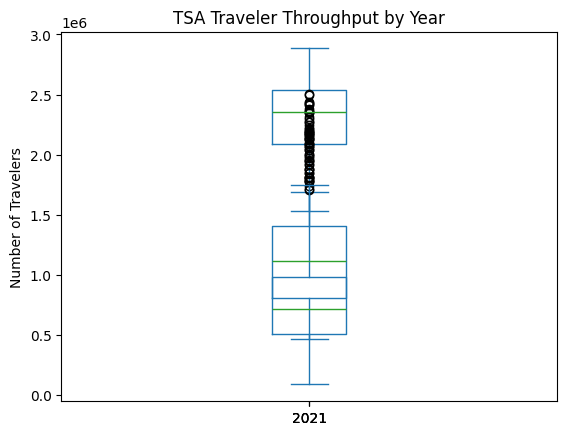

In [21]:

import matplotlib.pyplot as plt
tsa_data = pd.read_csv('tsa_melted_holiday_travel.csv')
tsa_data.groupby('year')['travelers'].plot(kind='box')
plt.title('TSA Traveler Throughput by Year')
plt.ylabel('Number of Travelers')
plt.show()


<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

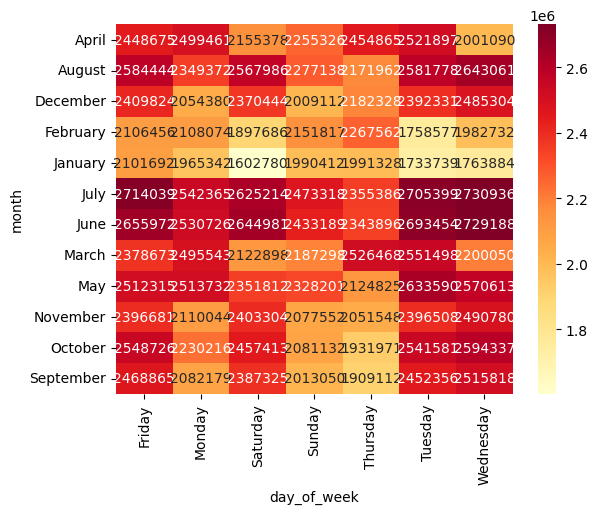

In [24]:

import seaborn as sns
tsa_data = pd.read_csv('tsa_melted_holiday_travel.csv')
tsa_2019 = tsa_data[tsa_data['year'] == 2019].copy()
tsa_2019['date'] = pd.to_datetime(tsa_2019['date'])
tsa_2019['day_of_week'] = tsa_2019['date'].dt.day_name()
tsa_2019['month'] = tsa_2019['date'].dt.month_name()
pivot_data = tsa_2019.groupby(['month', 'day_of_week'])['travelers'].median().unstack()
# [reordering code...]
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd')
plt.show()
